a

In [4]:
import pandas as pd
from bson import decode_file_iter
import numpy as np
import matplotlib.pyplot as plt

import regseq2

regseq2.viz.matplotlib_style()

ROOT = '../../data/regulonDB_14'

In [2]:
def bson_to_dataframe(path, max_docs=None):
    """
    Load a BSON file (concatenated BSON documents) into a pandas DataFrame.

    Parameters
    ----------
    path : str
        Path to .bson file
    max_docs : int or None
        Optional cap on number of documents to load (useful for debugging)

    Returns
    -------
    pandas.DataFrame
        One row per BSON document, keys become columns
    """
    records = []
    with open(path, "rb") as f:
        for i, doc in enumerate(decode_file_iter(f)):
            records.append(doc)
            if max_docs is not None and i + 1 >= max_docs:
                break

    return pd.DataFrame(records)


In [5]:
df = bson_to_dataframe(ROOT + '/regulondbdatamarts/regulonDatamart.bson')


regulator_list = []
gene_list = []
regulation_list = []
evidence_list = []
functional_list = []

FUNCTIONAL_EVIDENCE = [
    "Site mutation_S",
    "Inferred from mutant phenotype_W",
    "Inferred from genetic interaction_W",
    "Inferred from direct assay_W",
    "Inferred from experiment_W",
    "Gene expression analysis_W",
    "High-throughput RNA-seq evidence_W",
]

for _, row in df.iterrows():
    evidence = []
    for entry in row['allCitations']:
        functional = False
        if 'evidence' in entry.keys():
            ev = entry['evidence']['name'] + '_' + entry['evidence']['type']
            if ev in FUNCTIONAL_EVIDENCE:
                functional = True
            evidence.append(ev)
    # if len(evidence) == []:
    #     evidence_list.append("N")
    # elif 'S' in evidence:
    #     evidence_list.append("S")
    # elif 'W' in evidence:
    #     evidence_list.append("W")
    evidence_list.append(evidence)
    functional_list.append(functional)

    name = row['regulator']['abbreviatedName']
    regulator_list.append(name)
    sub_gene_list = []
    for gene in row['regulates']['genes']:
        sub_gene_list.append(gene['name'])
    gene_list.append(sub_gene_list)
    regulation_list.append(row['regulator']['type'])
    


df_regulation = pd.DataFrame(data={
    'regulator': regulator_list,
    'function': regulation_list,
    'genes': gene_list,
    'evidence': evidence_list,
    'functional': functional_list
})

df_regulation = df_regulation.explode("genes").rename(columns={"genes": "gene"}).reset_index(drop=True)
df_regulation.head()

,regulator,function,gene,evidence,functional
0,ppGpp,Allosteric-Regulation-of-RNAP,rrfA,"[High-throughput RNA-seq evidence_W, Inferred ...",True
1,ppGpp,Allosteric-Regulation-of-RNAP,rrlA,"[High-throughput RNA-seq evidence_W, Inferred ...",True
2,ppGpp,Allosteric-Regulation-of-RNAP,ileT,"[High-throughput RNA-seq evidence_W, Inferred ...",True
3,ppGpp,Allosteric-Regulation-of-RNAP,rrsA,"[High-throughput RNA-seq evidence_W, Inferred ...",True
4,ppGpp,Allosteric-Regulation-of-RNAP,alaT,"[High-throughput RNA-seq evidence_W, Inferred ...",True


In [6]:
len(df_regulation['gene'].unique())

2780

In [7]:
print(f"Number of genes with any regulatory annotation: {len(df_regulation['gene'].unique())}, {len(df_regulation['gene'].unique())/4747}%" )

Number of genes with any regulatory annotation: 2780, 0.5856330313882452%


In [7]:
df_regulation.groupby('function')['gene'].nunique()

function
Allosteric-Regulation-of-RNAP           394
RNA-Mediated-Translation-Regulation     252
Transcription-Factor-Binding           2675
Name: gene, dtype: int64

In [8]:
df_regulation[df_regulation['function'] == 'Allosteric-Regulation-of-RNAP']['regulator'].unique()

<StringArray>
['ppGpp', 'DksA']
Length: 2, dtype: str

In [9]:
df_regulation.groupby('function')['regulator'].nunique()

function
Allosteric-Regulation-of-RNAP            2
RNA-Mediated-Translation-Regulation     46
Transcription-Factor-Binding           242
Name: regulator, dtype: int64

In [10]:
len(df_regulation[df_regulation['evidence'] == 'S']['gene'].unique())

0

In [11]:
df_regulation[df_regulation['functional']].groupby('function')['gene'].nunique()

function
Allosteric-Regulation-of-RNAP           394
RNA-Mediated-Translation-Regulation     155
Transcription-Factor-Binding           1498
Name: gene, dtype: int64

In [12]:
print(2756/4651)
print(1498/4651)

0.592560739625887
0.32208127284454957


In [13]:
df = bson_to_dataframe(ROOT + '/regulondbdatamarts/regulonDatamart.bson')


tf_list = []
entity_id_list = []
entity_name_list = []
entity_type_list = []
regulation_list = []
bs_position_list = []
strand_list = []
dist_list = []
gene_list = []

for _, row in df.iterrows():
    name = row['regulator']['abbreviatedName']
    if row['regulator']['type'] == 'Transcription-Factor-Binding':
        for entry in row['regulatoryInteractions']:
            keys = list(entry.keys())
            if 'regulatoryBindingSites' in keys:
                
                binding_site = entry['regulatoryBindingSites']
                tf_list.append(name)

                if 'function' not in binding_site.keys():
                    regulation_list.append("missing")
                else:
                    regulation_list.append(binding_site['function'])

                if 'strand' not in binding_site.keys():
                    strand_list.append("missing")
                else:
                    strand_list.append(binding_site['strand'])

                if 'leftEndPosition' not in binding_site.keys():
                    bs_position_list.append("missing")
                else:
                    bs_position_list.append((binding_site['leftEndPosition'] + binding_site['rightEndPosition']) / 2)

                if 'regulatedEntity' in keys:
                    entity_id_list.append(entry['regulatedEntity']['_id'])
                    entity_name_list.append(entry['regulatedEntity']['name'])
                    entity_type_list.append(entry['regulatedEntity']['type'])
                else:
                    entity_id_list.append(entry['regulatedEntity']['_id'])
                    entity_name_list.append(entry['regulatedEntity']['name'])
                    entity_type_list.append(entry['regulatedEntity']['type'])

                if 'distanceToPromoter' in keys:
                    dist_list.append(entry['distanceToPromoter'])
                else:
                    dist_list.append('missing')

                sub_gene_list = []
                for gene in row['regulates']['genes']:
                    sub_gene_list.append(gene['name'])
                gene_list.append(sub_gene_list)

df_sites = pd.DataFrame(data={
    'tf': tf_list,
    'function': regulation_list,
    'strand': strand_list,
    'bs_position': bs_position_list,
    'regulated_entity_id': entity_id_list,
    'regulated_name': entity_name_list ,
    'regulated_type': entity_type_list,
    'distance': dist_list,
    'genes': gene_list
})

df_sites.head()

,tf,function,strand,bs_position,regulated_entity_id,regulated_name,regulated_type,distance,genes
0,ExuR,repressor,forward,3244858.5,RDBECOLIPMC03469,exuTp2,promoter,-143.5,"[lgoR, lgoD, exuT, uxaB, uxaC, uxaA, exuR, uxu..."
1,ExuR,repressor,reverse,1610866.5,RDBECOLIPMC00514,uxaBp,promoter,-146.5,"[lgoR, lgoD, exuT, uxaB, uxaC, uxaA, exuR, uxu..."
2,ExuR,repressor,reverse,3244858.5,RDBECOLIPMC02784,uxaCp2,promoter,-1.5,"[lgoR, lgoD, exuT, uxaB, uxaC, uxaA, exuR, uxu..."
3,ExuR,repressor,reverse,3244882.5,RDBECOLIPMC02784,uxaCp2,promoter,-25.5,"[lgoR, lgoD, exuT, uxaB, uxaC, uxaA, exuR, uxu..."
4,ExuR,repressor,reverse,3244803.5,RDBECOLIPMC02784,uxaCp2,promoter,54.5,"[lgoR, lgoD, exuT, uxaB, uxaC, uxaA, exuR, uxu..."


In [22]:
df_sites[df_sites['regulated_name'] == 'mtnp2']


,tf,function,strand,bs_position,regulated_entity_id,regulated_name,regulated_type,distance,genes


In [15]:
df_sites.to_csv('binding_sites.csv')

In [13]:
len(np.unique(np.hstack(df_sites['genes'].values)))

2672

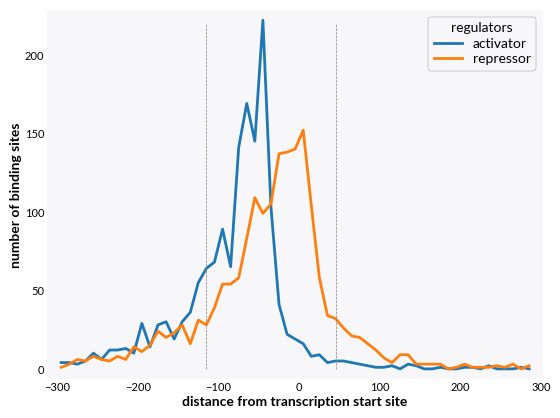

In [ ]:
fig, ax = plt.subplots()

df_filter = df_sites[(df_sites['distance'] != 'missing')]
df_filter.head()

for func in ['activator', 'repressor']:
    df_filter_act = df_filter[df_filter['function'] == func]
    distances_data = df_filter_act['distance'].values

    counts, bin_edges = np.histogram(distances_data, bins=np.arange(-300, 300, step=10))
    ax.plot([(bin_edges[i]+bin_edges[i+1])/2 for i in np.arange(len(bin_edges)-1)], counts, lw=2, label=func)

ax.vlines([-115, 45], ymin=0, ymax=220, ls='--', color='gray')
ax.legend(title='regulators', fontsize=10, title_fontsize=10)
ax.set_xlabel('distance from transcription start site', fontsize=10)
ax.set_ylabel('number of binding sites', fontsize=10)

#fig.savefig('../figures/binding_site_distances.pdf')

In [15]:
df_sig = bson_to_dataframe(ROOT + '/regulondbdatamarts/sigmulonDatamart.bson')

promoter_id_list = []
tss_list = []

for _,row in df_sig.iterrows():
    for entry in row['transcribedPromoters']:
        promoter_id_list.append(entry['_id'])
        if 'TSSPosition' in list(entry.keys()):
            tss_list.append(entry['TSSPosition'])
        else:
            tss_list.append('missing')

df_promoters = pd.DataFrame(data={'id': promoter_id_list, 'tss': tss_list})
df_promoters.head()

,id,tss
0,RDBECOLIPMC00020,2013205
1,RDBECOLIPMC00075,1492439
2,RDBECOLIPMC00350,1842188
3,RDBECOLIPMC00351,4327064
4,RDBECOLIPMC00352,4327079


In [23]:
df_sig['transcribedPromoters'].values[0][0]['transcribedGenes']

[{'_id': 'RDBECOLIGNC01317', 'distanceFromTSS': 24, 'name': 'fliF'},
 {'_id': 'RDBECOLIGNC01596', 'distanceFromTSS': 1675, 'name': 'fliG'},
 {'_id': 'RDBECOLIGNC01597', 'distanceFromTSS': 2663, 'name': 'fliH'},
 {'_id': 'RDBECOLIGNC02970', 'distanceFromTSS': 3349, 'name': 'fliI'},
 {'_id': 'RDBECOLIGNC02971', 'distanceFromTSS': 4741, 'name': 'fliJ'},
 {'_id': 'RDBECOLIGNC02972', 'distanceFromTSS': 5181, 'name': 'fliK'}]

In [232]:
df_promoter_merge = pd.merge(df_promoters, df_sites, how='inner', left_on='id', right_on='regulated_entity_id')
df_promoter_merge.head()

,id,tss,tf,function,strand,bs_position,regulated_entity_id,regulated_name,regulated_type,distance
0,RDBECOLIPMC00075,1492439,Fis,activator,forward,1492290.0,RDBECOLIPMC00075,trgp,promoter,-149.0
1,RDBECOLIPMC00075,1492439,Fis,activator,forward,1492379.0,RDBECOLIPMC00075,trgp,promoter,-60.0
2,RDBECOLIPMC00075,1492439,CRP,activator,forward,1492386.5,RDBECOLIPMC00075,trgp,promoter,-52.5
3,RDBECOLIPMC00418,1646388,Fis,activator,forward,1646316.0,RDBECOLIPMC00418,flxAp,promoter,-72.0
4,RDBECOLIPMC00419,2003676,GadE,activator,reverse,missing,RDBECOLIPMC00419,fliCp,promoter,missing


In [312]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _circular_window_counts(positions, genome_length, window_bp, step_bp):
    """
    Count features in a sliding window around a circular genome.

    positions: 0-based bp positions in [0, genome_length)
    Returns: centers (bp), theta (rad), win_counts (float)
    """
    pos = np.asarray(positions, dtype=np.int64)
    pos = pos[(pos >= 0) & (pos < genome_length)]

    n_bins = int(np.ceil(genome_length / step_bp))
    edges = np.arange(0, n_bins + 1) * step_bp
    edges[-1] = genome_length  # exact end
    centers = (edges[:-1] + edges[1:]) / 2.0

    # counts per step bin
    counts, _ = np.histogram(pos, bins=edges)

    # sliding window in "bin units"
    k = int(np.round(window_bp / step_bp))
    k = max(k, 1)
    kernel = np.ones(k, dtype=np.float64)

    # circular convolution via FFT
    fft_counts = np.fft.rfft(counts.astype(np.float64))
    kernel_padded = np.pad(kernel, (0, len(counts) - len(kernel)), constant_values=0)
    fft_kernel = np.fft.rfft(kernel_padded)
    win_counts = np.fft.irfft(fft_counts * fft_kernel, n=len(counts))

    theta = 2.0 * np.pi * (centers / genome_length)
    return centers.astype(np.int64), theta, win_counts

def genomic_clock_three_tracks(
    tss_pos,
    act_bs_pos,
    rep_bs_pos,
    genome_length,
    window_bp=10_000,
    step_bp=1_000,
    *,
    baselines=(60.0, 40.0, 20.0),   # (TSS, activator, repressor) ring radii
    scale_to_max=True,             # normalize each track to [0, 1] so rings compare visually
    clockwise=True,
    zero_at_top=True,
):
    """
    Polar 'genomic clock' with three concentric traces:
      - TSS density
      - Activator TFBS density
      - Repressor TFBS density
    """
    tracks = [
        ("TSS", tss_pos, baselines[0]),
        ("Activator TFBS", act_bs_pos, baselines[1]),
        ("Repressor TFBS", rep_bs_pos, baselines[2]),
    ]

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="polar")

    theta_plot_ref = None
    all_r_max = 0.0

    for label, pos, base in tracks:
        centers, theta, y = _circular_window_counts(pos, genome_length, window_bp, step_bp)

        if scale_to_max:
            ymax = y.max()
            amp = (y / ymax) if ymax > 0 else y  # avoid divide by zero
        else:
            amp = y

        r = base + amp

        # close loop
        theta_plot = np.concatenate([theta, theta[:1]])
        r_plot = np.concatenate([r, r[:1]])

        ax.plot(theta_plot, r_plot, lw=2, label=label)

        # optional: draw the baseline ring (zero line) faintly
        ax.plot(theta_plot, np.full_like(theta_plot, base), lw=1, alpha=0.3)

        all_r_max = max(all_r_max, float(np.max(r_plot)))
        theta_plot_ref = theta_plot

    if zero_at_top:
        ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1 if clockwise else 1)

    # cosmetics
    ax.set_rlim(0, all_r_max * 1.05)
    ax.set_yticklabels([])  # hide radial tick labels (optional)
    ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
    ax.set_title(f"Genome clock (window={window_bp} bp, step={step_bp} bp)", va="bottom")

    out = {
        "tss": pd.DataFrame({"center_bp": centers, "theta": theta, "count": _circular_window_counts(tss_pos, genome_length, window_bp, step_bp)[2]}),
        "act": pd.DataFrame({"center_bp": centers, "theta": theta, "count": _circular_window_counts(act_bs_pos, genome_length, window_bp, step_bp)[2]}),
        "rep": pd.DataFrame({"center_bp": centers, "theta": theta, "count": _circular_window_counts(rep_bs_pos, genome_length, window_bp, step_bp)[2]}),
    }
    return fig, ax, out


# ---- Example usage ----
# genome_len = 4_641_652
# tss_positions = df_tss["tss_pos0"].to_numpy()
# act_positions = df_act["site_pos0"].to_numpy()
# rep_positions = df_rep["site_pos0"].to_numpy()
# fig, ax, out = genomic_clock_three_tracks(tss_positions, act_positions, rep_positions, genome_len)
# plt.show()


(<Figure size 800x800 with 1 Axes>,
 <PolarAxes: title={'center': 'Genome clock (window=200000 bp, step=5000 bp)'}>,
 {'tss':      center_bp     theta  count
  0         2500  0.003384  135.0
  1         7500  0.010152  135.0
  2        12500  0.016921  131.0
  3        17500  0.023689  130.0
  4        22500  0.030457  122.0
  ..         ...       ...    ...
  924    4622500  6.257260  134.0
  925    4627500  6.264028  133.0
  926    4632500  6.270797  135.0
  927    4637500  6.277565  133.0
  928    4640826  6.282067  135.0
  
  [929 rows x 3 columns],
  'act':      center_bp     theta  count
  0         2500  0.003384   35.0
  1         7500  0.010152   35.0
  2        12500  0.016921   33.0
  3        17500  0.023689   35.0
  4        22500  0.030457   31.0
  ..         ...       ...    ...
  924    4622500  6.257260   36.0
  925    4627500  6.264028   36.0
  926    4632500  6.270797   37.0
  927    4637500  6.277565   34.0
  928    4640826  6.282067   35.0
  
  [929 rows x 3 colum

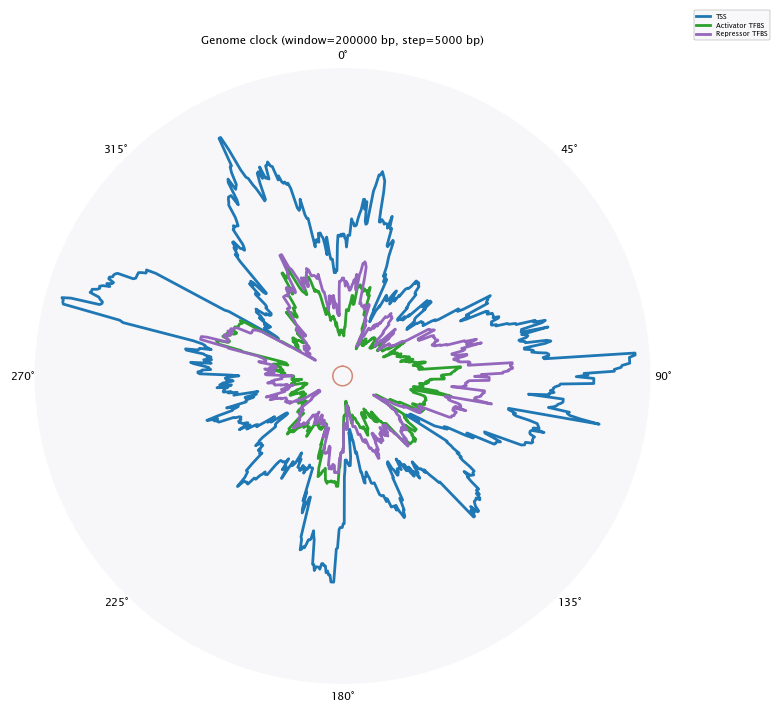

In [320]:
genomic_clock_three_tracks(
    tss_pos=df_promoter_merge[df_promoter_merge['tss'] != 'missing']['tss'].values, 
    act_bs_pos=df_promoter_merge[(df_promoter_merge['function'] == 'activator') & (df_promoter_merge['bs_position'] != 'missing')]['bs_position'].values,
    rep_bs_pos=df_promoter_merge[(df_promoter_merge['function'] == 'repressor') & (df_promoter_merge['bs_position'] != 'missing')]['bs_position'].values,
    genome_length=4_641_652,
    scale_to_max=False,
    window_bp=200_000,
    step_bp=5_000,
    baselines=[10, 10, 10]
    )

In [322]:
df_gene = bson_to_dataframe(ROOT + '/regulondbdatamarts/geneDatamart.bson')
len(df_gene)

4747